In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mragpavank/diabetes/diabetes.csv


# Diabetes Prediction with the Pima Indians Dataset

## 1. Introduction
This project predicts the onset of diabetes from diagnostic measurements (glucose, BMI, age, blood pressure and others) using the Pima Indians Diabetes Database. About 35% of patients in the data are diabetic, so the classes are mildly imbalanced. The aim is to build a scikit-learn pipeline and test whether a complex model beats a simple one.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mragpavank/diabetes/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Data cleaning
Glucose, blood pressure, skin thickness, insulin and BMI cannot be 0 in a living person, so zeros in these columns were treated as missing values. Insulin is missing in about half the rows (374 of 768) and skin thickness in about 30% (227). Missing values are filled inside the pipeline, using the training data only, to avoid data leakage.

In [4]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)
df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 3. Modelling
The data was split 80/20 into training and test sets, stratified by outcome. Each model is a pipeline of imputation, random over-sampling of the minority class, and the classifier. Over-sampling happens only on the training folds during cross-validation. Two models were tuned with GridSearchCV (5-fold): gradient boosting and a logistic regression baseline.

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Outcome")
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


In [6]:
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

clf = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomOverSampler(random_state=42),
    GradientBoostingClassifier(random_state=42),
)

params = {
    "simpleimputer__strategy": ["mean", "median"],
    "gradientboostingclassifier__n_estimators": [50, 100, 200],
    "gradientboostingclassifier__max_depth": [2, 3, 4],
}

model = GridSearchCV(clf, param_grid=params, cv=5, n_jobs=-1, verbose=1)
model.fit(X_train, y_train)
print(model.best_params_)
print(model.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
{'gradientboostingclassifier__max_depth': 3, 'gradientboostingclassifier__n_estimators': 50, 'simpleimputer__strategy': 'mean'}
0.7605757696921231


              precision    recall  f1-score   support

           0       0.86      0.76      0.81       100
           1       0.64      0.78      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.78      0.77      0.77       154



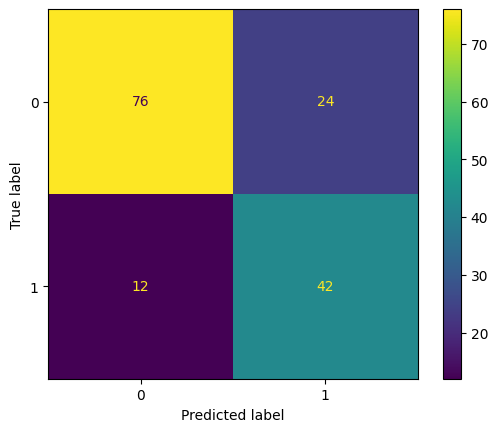

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


<Axes: >

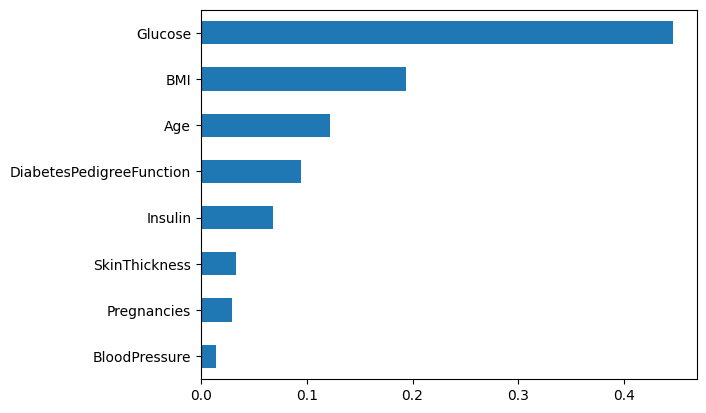

In [8]:
best = model.best_estimator_.named_steps["gradientboostingclassifier"]
pd.Series(best.feature_importances_, index=X.columns).sort_values().plot(kind="barh")

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

lr_clf = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomOverSampler(random_state=42),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)

lr_params = {
    "simpleimputer__strategy": ["mean", "median"],
    "logisticregression__C": [0.01, 0.1, 1, 10],
}

lr_model = GridSearchCV(lr_clf, param_grid=lr_params, cv=5, n_jobs=-1, verbose=1)
lr_model.fit(X_train, y_train)
print(lr_model.best_params_)
print(lr_model.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'logisticregression__C': 0.1, 'simpleimputer__strategy': 'median'}
0.7605890976942556


In [10]:
y_pred_lr = lr_model.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



## 4. Results
On the held-out test set (154 rows), gradient boosting scored higher than logistic regression (accuracy 0.766 vs 0.734, recall for diabetic patients 0.778 vs 0.704). However, cross-validated accuracy on the training data was identical (0.761 for both), and repeated cross-validation gave mean recall of 0.713 ± 0.07 for logistic regression and 0.702 ± 0.055 for gradient boosting.

In [11]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

results = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
    ],
    "Gradient Boosting": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ],
}, index=["Accuracy", "Precision (class 1)", "Recall (class 1)", "F1 (class 1)"]).round(3)

results

,Logistic Regression,Gradient Boosting
Accuracy,0.734,0.766
Precision (class 1),0.603,0.636
Recall (class 1),0.704,0.778
F1 (class 1),0.650,0.700


In [12]:
print("Logistic Regression CV:", lr_model.best_score_)
print("Gradient Boosting CV:  ", model.best_score_)

Logistic Regression CV: 0.7605890976942556
Gradient Boosting CV:   0.7605757696921231


## 5. Conclusion and limitations
Logistic regression and gradient boosting performed equivalently. Gradient boosting's higher test-set scores are best explained by the small test size, since a single patient changes recall by about 2 points. Because the simpler model performs as well, logistic regression is preferable: it is easier to interpret clinically, as each coefficient shows how a factor such as glucose or BMI shifts the odds of diabetes.

**Limitations:** small sample (768 rows), heavily missing insulin values, and a single train/test split. This is a learning project on a public dataset, not a clinical tool.

In [13]:
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
for name, m in [("Logistic Regression", lr_model.best_estimator_),
                ("Gradient Boosting", model.best_estimator_)]:
    scores = cross_val_score(m, X_train, y_train, cv=cv, scoring="recall")
    print(name, scores.mean().round(3), "+/-", scores.std().round(3))

Logistic Regression 0.713 +/- 0.07
Gradient Boosting 0.702 +/- 0.055
